In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models import resnet34

# 1. Конфигурация

In [2]:
DATA_DIR = "./data"
IMG_DIR = os.path.join(DATA_DIR, "train_images")
CSV_PATH = os.path.join(DATA_DIR, "train.csv")

IMG_SIZE = (224, 224)
BATCH_SIZE = 1024                # заполняем видеопамять (для ResNet34 ~2.5 ГБ)
EPOCHS = 50
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
torch.backends.cudnn.benchmark = True


In [4]:
df = pd.read_csv(CSV_PATH)
df["image"] = df["Image_Label"].apply(lambda x: x.split("_")[0])
df["class"] = df["Image_Label"].apply(lambda x: x.split("_")[1])
df["has_mask"] = ~df["EncodedPixels"].isna()  # True, если класс присутствует



In [8]:
df

,Image_Label,EncodedPixels,image,class,has_mask
0,0011165.jpg_Fish,264918 937 266318 937 267718 937 269118 937 27...,0011165.jpg,Fish,True
1,0011165.jpg_Flower,1355565 1002 1356965 1002 1358365 1002 1359765...,0011165.jpg,Flower,True
2,0011165.jpg_Gravel,NaN,0011165.jpg,Gravel,False
3,0011165.jpg_Sugar,NaN,0011165.jpg,Sugar,False
4,002be4f.jpg_Fish,233813 878 235213 878 236613 878 238010 881 23...,002be4f.jpg,Fish,True
...,...,...,...,...,...
22179,ffd6680.jpg_Sugar,NaN,ffd6680.jpg,Sugar,False
22180,ffea4f4.jpg_Fish,NaN,ffea4f4.jpg,Fish,False
22181,ffea4f4.jpg_Flower,1194860 675 1196260 675 1197660 675 1199060 67...,ffea4f4.jpg,Flower,True
22182,ffea4f4.jpg_Gravel,NaN,ffea4f4.jpg,Gravel,False


In [5]:
# Уникальные изображения и их метки (multi-hot)
image_names = df["image"].unique()
label_map = {}
for name in image_names:
    sub = df[df["image"] == name]
    labels = np.zeros(4, dtype=np.float32)
    for _, row in sub.iterrows():
        if row["has_mask"]:
            cls_idx = {"Sugar":0, "Fish":1, "Flower":2, "Gravel":3}[row["class"]]
            labels[cls_idx] = 1.0
    label_map[name] = labels


#train_imgs, val_imgs = train_test_split(image_names, test_size=0.2, random_state=42)
bigs, smalls = train_test_split(df, test_size=0.2, random_state=42, stratify=df["class"])
image_names = smalls["image"].unique()
train_imgs, val_imgs = train_test_split(image_names, test_size=0.2, random_state=42)

# 2. Кэширование всех изображений в ОЗУ (PIL после resize)

In [6]:
print("Кэширование тренировочных изображений в память...")
train_pil_cache = {}
for name in tqdm(train_imgs):
    img = Image.open(os.path.join(IMG_DIR, name)).convert("RGB")
    img = img.resize(IMG_SIZE, Image.BILINEAR)   # ресайз один раз
    train_pil_cache[name] = img

print("Кэширование валидационных изображений...")
val_pil_cache = {}
for name in tqdm(val_imgs):
    img = Image.open(os.path.join(IMG_DIR, name)).convert("RGB")
    img = img.resize(IMG_SIZE, Image.BILINEAR)
    val_pil_cache[name] = img

Кэширование тренировочных изображений в память...


100%|██████████| 2620/2620 [03:50<00:00, 11.36it/s]


Кэширование валидационных изображений...


100%|██████████| 656/656 [00:49<00:00, 13.38it/s]


In [10]:
# Трансформации БЕЗ Resize (изображения уже 224x224)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [13]:
class CloudClassificationCachedDataset(Dataset):
    def __init__(self, img_names, pil_cache, label_map, transform=None):
        self.img_names = img_names
        self.pil_cache = pil_cache
        self.label_map = label_map
        self.transform = transform

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        name = self.img_names[idx]
        image = self.pil_cache[name]          # PIL Image уже 224x224
        labels = torch.tensor(self.label_map[name], dtype=torch.float32)
        if self.transform:
            image = self.transform(image)
        return image, labels


In [14]:
train_dataset = CloudClassificationCachedDataset(train_imgs, train_pil_cache, label_map, transform=train_transform)
val_dataset = CloudClassificationCachedDataset(val_imgs, val_pil_cache, label_map, transform=val_transform)

# Загрузчики: num_workers=0 (данные уже в памяти), pin_memory=True
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=True)


# 3. Модель: ResNet34 с заменой последнего слоя

In [21]:
model = resnet34(weights="IMAGENET1K_V1")
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)
model = model.to(DEVICE)

# Компиляция модели (PyTorch 2.0+) – даёт прирост ~20-30%
if hasattr(torch, 'compile'):
    model = torch.compile(model, backend='aot_eager')
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
scaler = torch.cuda.amp.GradScaler(enabled=DEVICE.type == 'cuda')


C:\Users\Admin\AppData\Local\Temp\ipykernel_22268\1186942022.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=DEVICE.type == 'cuda')


# 4. Метрика Dice для multi-label

In [22]:
def dice_coef_multi(pred_logits, targets, threshold=0.5, smooth=1e-6):
    preds = torch.sigmoid(pred_logits) > threshold
    preds = preds.float()
    intersection = (preds * targets).sum(dim=0)
    union = preds.sum(dim=0) + targets.sum(dim=0)
    dice_per_class = (2. * intersection + smooth) / (union + smooth)
    return dice_per_class.mean().item()

# 5. Обучение с AMP и ранней остановкой

In [23]:
best_val_dice = 0.0
patience = 7
epochs_no_improve = 0
early_stop = False

train_loss_history = []
val_dice_history = []

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]")
    for imgs, labels in loop:
        imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=DEVICE.type == 'cuda'):
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * imgs.size(0)
        loop.set_postfix(loss=loss.item())
    epoch_loss = running_loss / len(train_dataset)
    train_loss_history.append(epoch_loss)

    # Валидация
    model.eval()
    total_dice = 0.0
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]"):
            imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=DEVICE.type == 'cuda'):
                outputs = model(imgs)
            dice = dice_coef_multi(outputs, labels)
            total_dice += dice * imgs.size(0)
    epoch_val_dice = total_dice / len(val_dataset)
    val_dice_history.append(epoch_val_dice)

    print(f"Epoch {epoch:2d} | Train Loss: {epoch_loss:.4f} | Val Dice: {epoch_val_dice:.4f}")

    scheduler.step(epoch_val_dice)

    if epoch_val_dice > best_val_dice:
        best_val_dice = epoch_val_dice
        torch.save(model.state_dict(), "best_model_classification.pth")
        epochs_no_improve = 0
        print(f"--> New best Dice: {best_val_dice:.4f}. Model saved.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch} epochs.")
            early_stop = True
            break

if not early_stop:
    print(f"Training finished. Best Val Dice: {best_val_dice:.4f}")
else:
    print(f"Training stopped early. Best Val Dice: {best_val_dice:.4f}")

Epoch 1/50 [Train]:   0%|          | 0/2 [00:00<?, ?it/s]C:\Users\Admin\AppData\Local\Temp\ipykernel_22268\2179172753.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=DEVICE.type == 'cuda'):
Epoch 1/50 [Train]:  50%|█████     | 1/2 [07:07<07:07, 427.02s/it, loss=0.765]C:\Users\Admin\AppData\Local\Temp\ipykernel_22268\2179172753.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=DEVICE.type == 'cuda'):
Epoch 1/50 [Val]:   0%|          | 0/1 [00:00<?, ?it/s]C:\Users\Admin\AppData\Local\Temp\ipykernel_22268\2179172753.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=DEVICE.type == 'cuda'):
Epoch 1/50 [Val]: 100%|██████████| 1/1 [00:13<00

Epoch  1 | Train Loss: 0.5532 | Val Dice: 0.3267
--> New best Dice: 0.3267. Model saved.


Epoch 2/50 [Train]:   0%|          | 0/2 [00:00<?, ?it/s]C:\Users\Admin\AppData\Local\Temp\ipykernel_22268\2179172753.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=DEVICE.type == 'cuda'):
Epoch 2/50 [Val]:   0%|          | 0/1 [00:00<?, ?it/s]C:\Users\Admin\AppData\Local\Temp\ipykernel_22268\2179172753.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=DEVICE.type == 'cuda'):
Epoch 2/50 [Val]: 100%|██████████| 1/1 [00:02<00:00,  2.72s/it]


Epoch  2 | Train Loss: 0.4947 | Val Dice: 0.1522


Epoch 3/50 [Val]: 100%|██████████| 1/1 [00:02<00:00,  2.67s/it]


...

Epoch 24 | Train Loss: 0.1979 | Val Dice: 0.7155


Epoch 25/50 [Val]: 100%|██████████| 1/1 [00:03<00:00,  3.58s/it]


Epoch 25 | Train Loss: 0.1776 | Val Dice: 0.7288


Epoch 26/50 [Val]: 100%|██████████| 1/1 [00:03<00:00,  3.36s/it]

Epoch 26 | Train Loss: 0.1778 | Val Dice: 0.7208
Early stopping triggered after 26 epochs.
Training stopped early. Best Val Dice: 0.7483


# 6. Графики обучения

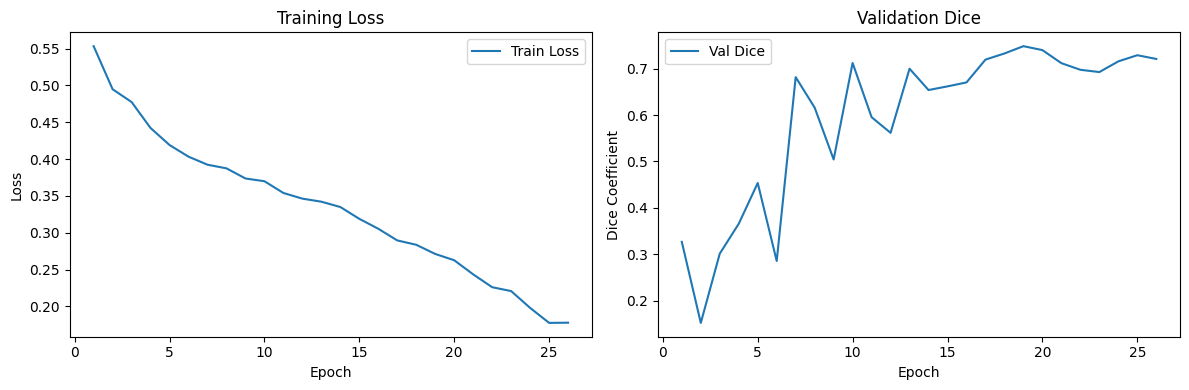

In [24]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(1, len(train_loss_history)+1), train_loss_history, label='Train Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training Loss'); plt.legend()

plt.subplot(1,2,2)
plt.plot(range(1, len(val_dice_history)+1), val_dice_history, label='Val Dice')
plt.xlabel('Epoch'); plt.ylabel('Dice Coefficient'); plt.title('Validation Dice'); plt.legend()
plt.tight_layout()
plt.savefig('training_plot_classification.png')
plt.show()


# 7. Визуализация 9 примеров с предсказанными классами

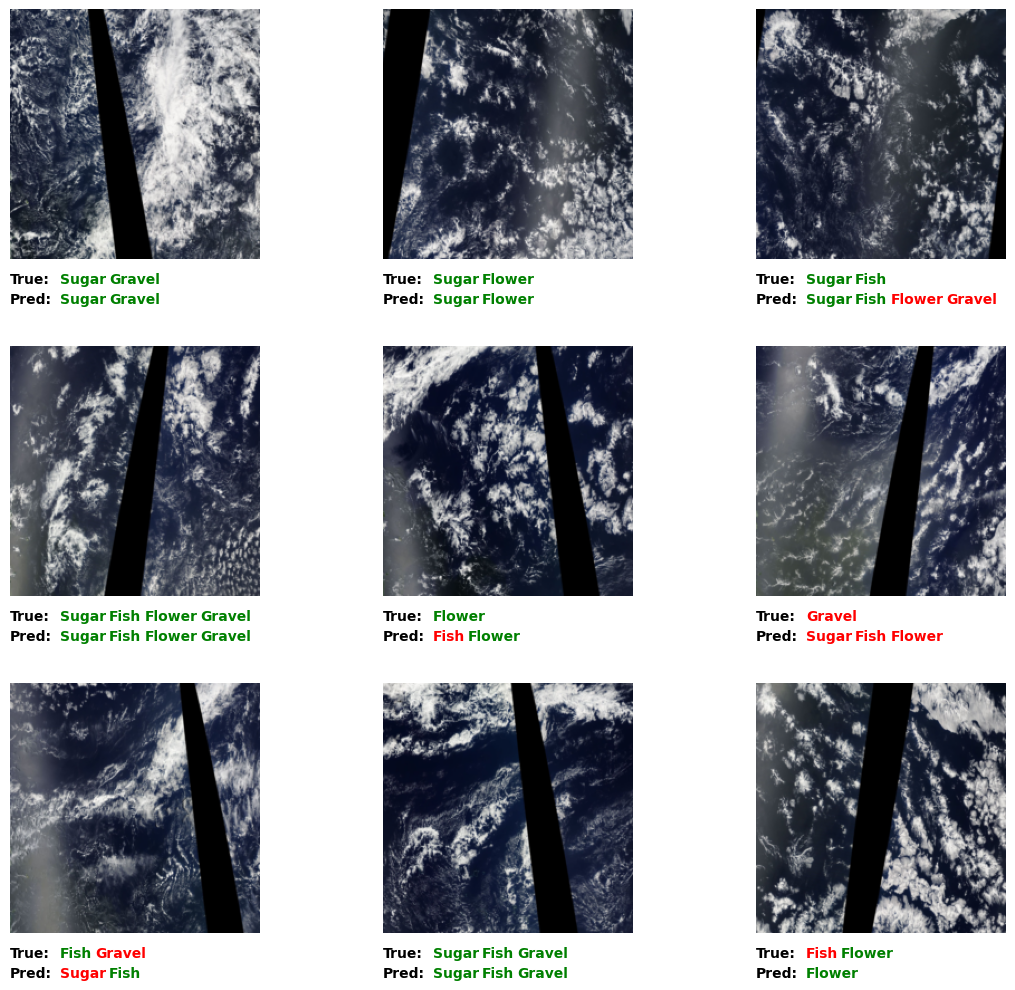

In [33]:
# -------------------------------
# 7. Финальная визуализация: крупные картинки + компактные цветные подписи
# -------------------------------
model.load_state_dict(torch.load("best_model_classification.pth"))
model.eval()

class_names = ["Sugar", "Fish", "Flower", "Gravel"]

def tensor_to_img(tensor):
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    tensor = inv_normalize(tensor)
    tensor = torch.clamp(tensor, 0, 1)
    return tensor.permute(1,2,0).cpu().numpy()

np.random.seed(42)
indices = np.random.choice(len(val_dataset), 9, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()
plt.subplots_adjust(wspace=0.1, hspace=0.35)  # компактно, но с местом для подписей

def draw_colored_row(ax, x_start, y, items, fontsize=9):
    """
    Рисует горизонтальный ряд цветных слов, начиная с x_start.
    items: список (color, word)
    Возвращает конечную координату x.
    """
    renderer = fig.canvas.get_renderer()
    cur_x = x_start
    for color, word in items:
        t = ax.text(cur_x, y, word, transform=ax.transAxes, ha='left', va='center',
                    fontsize=fontsize, color=color, fontweight='bold')
        plt.draw()  # обновить для измерения
        bbox = t.get_window_extent(renderer=renderer)
        # ширина в относительных координатах Axes
        word_width = bbox.width / fig.dpi / (ax.get_position().width * fig.get_size_inches()[0])
        cur_x += word_width + 0.012  # небольшой отступ между словами
    return cur_x

for idx, ax in zip(indices, axes):
    img_tensor, true_labels = val_dataset[idx]
    img_disp = tensor_to_img(img_tensor)
    with torch.no_grad():
        logits = model(img_tensor.unsqueeze(0).to(DEVICE))
        pred_probs = torch.sigmoid(logits).cpu().numpy()[0]
    pred_binary = (pred_probs > 0.5).astype(int)
    true_binary = true_labels.numpy().astype(int)

    # Списки цветных элементов для True и Pred
    true_items = []
    pred_items = []
    for i, name in enumerate(class_names):
        if true_binary[i] == 1:
            if pred_binary[i] == 1:
                true_items.append(('green', name))   # TP
            else:
                true_items.append(('red', name))     # FN
        if pred_binary[i] == 1:
            if true_binary[i] == 1:
                pred_items.append(('green', name))   # TP
            else:
                pred_items.append(('red', name))     # FP

    # Отображаем крупное изображение
    ax.imshow(img_disp)
    ax.axis('off')

    # Рисуем подписи ПОД картинкой (y < 0)
    # Метка "True:"
    ax.text(0.0, -0.08, "True:", transform=ax.transAxes, ha='left', va='center',
            fontsize=10, fontweight='bold', color='black')
    if true_items:
        draw_colored_row(ax, 0.2, -0.08, true_items, fontsize=10)
    else:
        ax.text(0.1, -0.08, "None", transform=ax.transAxes, ha='left', va='center',
                fontsize=10, color='gray')

    # Метка "Pred:"
    ax.text(0.0, -0.16, "Pred:", transform=ax.transAxes, ha='left', va='center',
            fontsize=10, fontweight='bold', color='black')
    if pred_items:
        draw_colored_row(ax, 0.2, -0.16, pred_items, fontsize=10)
    else:
        ax.text(0.1, -0.16, "None", transform=ax.transAxes, ha='left', va='center',
                fontsize=10, color='gray')

plt.savefig('visualization_clean.png', bbox_inches='tight')
plt.show()

# **Результаты и оценка модели**
Мы провели обучение и оценку нейросети на задаче классификации типов облаков (задача многометочной классификации, классы: Sugar, Flower, Fish, Gravel).  
  
1. Динамика обучения
Процесс обучения длился 26 эпох и показал стабильную сходимость.

Функция потерь на обучении (Training Loss, слева): График демонстрирует плавное и последовательное снижение ошибки. Значение потерь начинается с ~0.55 и выходит на плато около 0.17–0.18. Это говорит о том, что оптимизатор эффективно минимизирует ошибку на тренировочной выборке.

Коэффициент Dice на валидации (Validation Dice, справа): Метрика Dice (которая хорошо подходит для задач с дисбалансом классов) показывает заметную волатильность на ранних эпохах (с 5 по 15), что характерно в процессе изучения признакового пространства. Однако, начиная с 15–20-й эпохи, значение стабилизируется и достигает максимума примерно на уровне 0.73–0.75.

2. Качественный анализ предсказаний
Ниже приведена выборка из 9 случайных изображений из валидационной выборки. Подписи над картинками указывают истинные метки (True) и предсказанные моделью метки (Pred).


## Ключевые наблюдения:

Способность к многометочной классификации: Модель успешно справляется с наложением облачных структур и корректно идентифицирует несколько классов на одном снимке (например, правильно определяя комбинации Sugar, Fish, Flower, Gravel).

## Характерные ошибки: 

Несмотря на хорошую работу на чистых примерах, модель иногда ошибается:

Избыточные предсказания: Предсказывает лишние классы (например, предсказывает Fish, Flower, когда истинная метка только Flower).

## Пропущенные классы:  
Не определяет какой-либо облачный тип (например, предсказывает только Flower при истинной метке Fish, Flower, или полностью игнорирует класс Gravel в одном из примеров).

Влияние артефактов данных: На спутниковых снимках присутствует заметная диагональная черная полоса (пропущенные данные). Этот артефакт перекрывает часть поля облаков, что, вероятно, и вносит основной вклад в ошибки классификации, наблюдаемые на центральных и правых колонках.

# **Заключение**
Модель демонстрирует хороший метрический результат (коэффициент Dice ~0.75) и стабильную сходимость в процессе обучения. Визуальный анализ предсказаний подтверждает, что нейросеть выучила характерные паттерны облачных структур разных типов и эффективно решает задачу множественной классификации.

Тем не менее, наличие шума и артефактов (пропусков в данных) указывает на перспективу дальнейшего улучшения модели. В качестве следующих шагов можно рекомендовать использование методов аугментации данных (специфичных для затемнения артефактов) либо внедрение механизмов внимания (Attention), чтобы модель могла игнорировать области с отсутствующими данными.